# Best Model Evaluation on Validation Dataset

This notebook evaluates the best BiSeNetV2 model from the latest or pre-latest communication rounds on the validation dataset. It calculates:
- Per-class IoU scores
- mIoU using all 19 classes
- mIoU using only majority classes (excluding: Traffic Light, Traffic Sign, Pole, Train, Motorcycle, Rider)

## Section 1: Import Required Libraries

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
import torch
from tqdm import tqdm

# Add project root to path
project_root = '/home/moustafa/Me/Projects/Grad/Code/BiseNet-FL'
sys.path.insert(0, project_root)
sys.path.insert(0, os.path.join(project_root, 'fl-cityscapes-bisenetv2'))

# Import from the project
from lib.models import BiSeNetV2
from lib.ohem_ce_loss import OhemCELoss
from tools.eval_metrics import compute_metrics_from_cm
from fl_cityscapes_bisenetv2.data_preparation.datasets import load_server_eval_data

print("Libraries imported successfully!")
print(f"Project root: {project_root}")

Libraries imported successfully!
Project root: /home/moustafa/Me/Projects/Grad/Code/BiseNet-FL


## Section 2: Define Class Names and Configuration

In [2]:
# Cityscapes class names (19 classes with trainId)
CLASS_NAMES = {
    0: "road",
    1: "sidewalk",
    2: "building",
    3: "wall",
    4: "fence",
    5: "pole",
    6: "traffic light",
    7: "traffic sign",
    8: "vegetation",
    9: "terrain",
    10: "sky",
    11: "person",
    12: "rider",
    13: "car",
    14: "truck",
    15: "bus",
    16: "train",
    17: "motorcycle",
    18: "bicycle",
}

# Minority classes to exclude
MINORITY_CLASSES = {
    "traffic light": 6,
    "traffic sign": 7,
    "pole": 5,
    "train": 16,
    "motorcycle": 17,
    "rider": 12,
}

# Majority class indices (all classes except minority)
MAJORITY_CLASS_INDICES = set(range(19)) - set(MINORITY_CLASSES.values())

# Configuration
NUM_CLASSES = 19
LB_IGNORE = 255
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Majority classes: {sorted([CLASS_NAMES[i] for i in MAJORITY_CLASS_INDICES])}")
print(f"Minority classes: {list(MINORITY_CLASSES.keys())}")

Device: cuda
Number of classes: 19
Majority classes: ['bicycle', 'building', 'bus', 'car', 'fence', 'person', 'road', 'sidewalk', 'sky', 'terrain', 'truck', 'vegetation', 'wall']
Minority classes: ['traffic light', 'traffic sign', 'pole', 'train', 'motorcycle', 'rider']


## Section 3: Configuration Parameters

**Update these parameters according to your setup:**

In [ ]:
# ============= CONFIGURATION PARAMETERS =============
# Partition types to evaluate (IID vs NON-IID data distributions)
PARTITION_IDS = ["IID_Partition", "Non_IID_Partition"]

# Aggregators to evaluate
AGGREGATORS = ["FedAvg", "FedProx"]

# Path to the results directory containing partition subdirectories
RESULTS_ROOT = '/home/moustafa/Me/Projects/Grad/Experiments/First_Trial'

# Path to Cityscapes dataset
CITYSCAPES_ROOT = '/home/moustafa/Me/Projects/Grad/Code/BiseNet-FL/datasets/cityscapes'

# Validation data partition file
VAL_PARTITION_FILE = os.path.join(CITYSCAPES_ROOT, "val.txt")

# Batch size for evaluation
EVAL_BATCH_SIZE = 4

# Model file name to search for (best_model.pt or latest_model.pt)
MODEL_FILENAME = "best_model.pt"

print(f"Partition types to evaluate: {PARTITION_IDS}")
print(f"Aggregators to evaluate: {AGGREGATORS}")
print(f"Results root: {RESULTS_ROOT}")
print(f"Cityscapes root: {CITYSCAPES_ROOT}")
print(f"Validation partition file: {VAL_PARTITION_FILE}")
print(f"Eval batch size: {EVAL_BATCH_SIZE}")

Partition types to evaluate: ['IID_Partition', 'Non_IID_Partition']
Aggregators to evaluate: ['FedAvg', 'FedProx']
Results root: /home/moustafa/Me/Projects/Grad/Experiments/First_Trial
Cityscapes root: /home/moustafa/Me/Projects/Grad/Code/BiseNet-FL/datasets/cityscapes
Validation partition file: /home/moustafa/Me/Projects/Grad/Code/BiseNet-FL/datasets/cityscapes/val.txt
Eval batch size: 4


## Section 4: Load Best Model from Latest Rounds

In [4]:
def find_best_model_paths(results_root, partition_types, aggregators, model_filename="best_model.pt"):
    """
    Find best model paths from the last communication round in checkpoints directories.
    
    Directory structure:
        RESULTS_ROOT/
        ├── IID_Partition/
        │   ├── FedAvg/
        │   │   └── checkpoints/
        │   │       ├── 1/
        │   │       ├── 2/
        │   │       └── 3/ (last)
        │   │           └── best_model.pt
        │   └── FedProx/
        │       └── checkpoints/
        │           └── ...
        └── Non_IID_Partition/
            └── ...
    
    Args:
        results_root: Root directory containing partition types
        partition_types: List of partition type names (e.g., ["IID_Partition", "Non_IID_Partition"])
        aggregators: List of aggregator names (e.g., ["FedAvg", "FedProx"])
        model_filename: Name of the model file to search for
    
    Returns:
        Dictionary with (partition_type, aggregator) -> best_model_path mappings
    """
    model_paths = {}
    
    if not os.path.exists(results_root):
        print(f"Results directory not found: {results_root}")
        return model_paths
    
    for partition_type in partition_types:
        partition_path = os.path.join(results_root, partition_type)
        
        if not os.path.exists(partition_path):
            print(f"\n⚠ Partition type directory not found: {partition_path}")
            continue
        
        print(f"\n{'='*70}")
        print(f"Partition Type: {partition_type}")
        print(f"{'='*70}")
        
        for aggregator in aggregators:
            aggregator_path = os.path.join(partition_path, aggregator)
            
            if not os.path.exists(aggregator_path):
                print(f"  ⚠ {aggregator}: Directory not found at {aggregator_path}")
                continue
            
            checkpoints_path = os.path.join(aggregator_path, "checkpoints")
            
            if not os.path.exists(checkpoints_path):
                print(f"  ⚠ {aggregator}: checkpoints directory not found")
                continue
            
            # Get all round directories (should be numeric names)
            round_dirs = []
            try:
                for d in os.listdir(checkpoints_path):
                    dir_path = os.path.join(checkpoints_path, d)
                    if os.path.isdir(dir_path):
                        try:
                            round_num = int(d)
                            round_dirs.append(round_num)
                        except ValueError:
                            # Skip non-numeric directories
                            pass
            except Exception as e:
                print(f"  ✗ {aggregator}: Error reading checkpoints directory: {e}")
                continue
            
            if not round_dirs:
                print(f"  ⚠ {aggregator}: No numeric round directories found in checkpoints")
                continue
            
            # Sort and get the last round
            round_dirs.sort()
            last_round = round_dirs[-1]
            
            model_path = os.path.join(checkpoints_path, str(last_round), model_filename)
            
            if os.path.exists(model_path):
                model_paths[(partition_type, aggregator)] = model_path
                print(f"  ✓ {aggregator}: Found best_model.pt in round {last_round}")
            else:
                print(f"  ✗ {aggregator}: {model_filename} not found in round {last_round}")
    
    return model_paths

# Find best models for all partition types and aggregators
model_paths = find_best_model_paths(RESULTS_ROOT, PARTITION_IDS, AGGREGATORS, MODEL_FILENAME)

if not model_paths:
    print("\n✗ No models found. Please check the configuration parameters.")
else:
    print(f"\n{'='*70}")
    print(f"✓ Total models found: {len(model_paths)}")
    print(f"{'='*70}")


Partition Type: IID_Partition
  ✓ FedAvg: Found best_model.pt in round 450
  ✓ FedProx: Found best_model.pt in round 340

Partition Type: Non_IID_Partition
  ✓ FedAvg: Found best_model.pt in round 360
  ✓ FedProx: Found best_model.pt in round 530

✓ Total models found: 4


## Section 5: Load Validation Dataset

In [5]:
# Load validation dataset
print("Loading validation dataset...")

try:
    eval_loader = load_server_eval_data(
        data_root=CITYSCAPES_ROOT,
        data_file=VAL_PARTITION_FILE,
        batch_size=EVAL_BATCH_SIZE,
    )
    print(f"✓ Validation dataset loaded successfully")
    print(f"  Total batches: {len(eval_loader)}")
    print(f"  Batch size: {EVAL_BATCH_SIZE}")
except Exception as e:
    print(f"✗ Error loading validation dataset: {e}")
    raise

Loading validation dataset...
✓ Validation dataset loaded successfully
  Total batches: 125
  Batch size: 4


## Section 6: Evaluate Model and Compute Confusion Matrix

In [6]:
def evaluate_model(model, eval_loader, device, num_classes, lb_ignore=255):
    """
    Evaluate model on validation dataset and compute confusion matrix.
    Follows the same approach as task.py's test() function.
    
    Args:
        model: BiSeNetV2 model
        eval_loader: DataLoader for validation data
        device: torch device
        num_classes: Number of classes
        lb_ignore: Label to ignore (typically 255)
    
    Returns:
        conf_matrix: Confusion matrix (num_classes x num_classes)
    """
    model.to(device)
    org_aux = model.aux_mode if hasattr(model, 'aux_mode') else None
    if hasattr(model, 'aux_mode'):
        model.aux_mode = "eval"
    model.eval()
    
    conf_matrix = np.zeros((num_classes, num_classes), dtype=np.int64)
    
    with torch.no_grad():
        for batch_idx, (im, lb) in enumerate(tqdm(eval_loader, desc="Evaluating")):
            images = im.to(device)
            labels = lb.to(device)
            
            # Get predictions
            logits = model(images)[0]  # Only use main output, not aux
            preds = torch.softmax(logits, dim=1).argmax(dim=1)
            
            # Convert to numpy
            preds_np = preds.cpu().numpy().reshape(-1)
            labels_np = labels.cpu().numpy().reshape(-1)
            
            # Filter out ignored labels
            mask = labels_np != lb_ignore
            preds_np = preds_np[mask]
            labels_np = labels_np[mask]
            
            # Update confusion matrix
            conf_matrix += np.bincount(
                labels_np * num_classes + preds_np,
                minlength=num_classes**2,
            ).reshape(num_classes, num_classes)
    
    if org_aux is not None and hasattr(model, 'aux_mode'):
        model.aux_mode = org_aux
    
    return conf_matrix

# Evaluate all models found
all_results = {}

for (partition_type, aggregator), model_path in model_paths.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: [{partition_type}] {aggregator}")
    print(f"{'='*60}")
    print(f"Model path: {model_path}")
    
    # Load model
    try:
        model = BiSeNetV2(NUM_CLASSES)
        state_dict = torch.load(model_path, map_location=DEVICE)
        model.load_state_dict(state_dict, strict=True)
        model.to(DEVICE)
        print(f"✓ Model loaded successfully")
    except Exception as e:
        print(f"✗ Error loading model: {e}")
        continue
    
    # Evaluate model
    try:
        conf_matrix = evaluate_model(model, eval_loader, DEVICE, NUM_CLASSES, LB_IGNORE)
        all_results[(partition_type, aggregator)] = conf_matrix
        print(f"✓ Evaluation completed successfully")
    except Exception as e:
        print(f"✗ Error during evaluation: {e}")
        continue
    finally:
        del model
        torch.cuda.empty_cache()

print(f"\n{'='*60}")
print(f"Total models evaluated: {len(all_results)}")
print(f"{'='*60}")


Evaluating: [IID_Partition] FedAvg
Model path: /home/moustafa/Me/Projects/Grad/Experiments/First_Trial/IID_Partition/FedAvg/checkpoints/450/best_model.pt
✓ Model loaded successfully


Evaluating: 100%|██████████| 125/125 [01:10<00:00,  1.78it/s]


✓ Evaluation completed successfully

Evaluating: [IID_Partition] FedProx
Model path: /home/moustafa/Me/Projects/Grad/Experiments/First_Trial/IID_Partition/FedProx/checkpoints/340/best_model.pt
✓ Model loaded successfully


Evaluating: 100%|██████████| 125/125 [01:25<00:00,  1.45it/s]


✓ Evaluation completed successfully

Evaluating: [Non_IID_Partition] FedAvg
Model path: /home/moustafa/Me/Projects/Grad/Experiments/First_Trial/Non_IID_Partition/FedAvg/checkpoints/360/best_model.pt
✓ Model loaded successfully


Evaluating: 100%|██████████| 125/125 [01:41<00:00,  1.24it/s]


✓ Evaluation completed successfully

Evaluating: [Non_IID_Partition] FedProx
Model path: /home/moustafa/Me/Projects/Grad/Experiments/First_Trial/Non_IID_Partition/FedProx/checkpoints/530/best_model.pt
✓ Model loaded successfully


Evaluating: 100%|██████████| 125/125 [02:02<00:00,  1.02it/s]

✓ Evaluation completed successfully

Total models evaluated: 4


## Section 7: Calculate Per-Class IoU

In [7]:
def compute_per_class_iou(conf_matrix):
    """
    Compute per-class IoU from confusion matrix.
    
    Args:
        conf_matrix: Confusion matrix (num_classes x num_classes)
    
    Returns:
        iou_per_class: Array of IoU values for each class
    """
    TP = np.diag(conf_matrix)
    FP = np.sum(conf_matrix, axis=0) - TP
    FN = np.sum(conf_matrix, axis=1) - TP
    
    with np.errstate(divide='ignore', invalid='ignore'):
        iou_per_class = TP / (TP + FP + FN)
    
    iou_per_class[np.isnan(iou_per_class)] = 0.0
    
    return iou_per_class

# Compute per-class IoU for all partitions and aggregators
partition_results = {}

for (partition_type, aggregator), conf_matrix in all_results.items():
    iou_per_class = compute_per_class_iou(conf_matrix)
    metrics_all = compute_metrics_from_cm(conf_matrix)
    
    # Compute metrics for majority classes only
    majority_iou = iou_per_class[list(MAJORITY_CLASS_INDICES)]
    metrics_majority = {
        'mIoU_majority': np.mean(majority_iou) if len(majority_iou) > 0 else 0.0
    }
    
    partition_results[(partition_type, aggregator)] = {
        'conf_matrix': conf_matrix,
        'iou_per_class': iou_per_class,
        'metrics_all_classes': metrics_all,
        'metrics_majority_classes': metrics_majority,
    }

print(f"\n{'='*70}")
print("RESULTS SUMMARY - Per-Class IoU")
print(f"{'='*70}\n")

# Display results organized by partition type, then by aggregator
for partition_type in PARTITION_IDS:
    print(f"\n{'='*70}")
    print(f"Partition Type: {partition_type}")
    print(f"{'='*70}\n")
    
    for aggregator in AGGREGATORS:
        key = (partition_type, aggregator)
        
        if key not in partition_results:
            print(f"\n⚠ {aggregator}: No results available")
            continue
        
        results = partition_results[key]
        iou_per_class = results['iou_per_class']
        metrics_all = results['metrics_all_classes']
        metrics_majority = results['metrics_majority_classes']
        
        print(f"\n{'-'*70}")
        print(f"Aggregator: {aggregator}")
        print(f"{'-'*70}")
        
        # Create a nice table for display
        df_iou = pd.DataFrame({
            'Class ID': range(NUM_CLASSES),
            'Class Name': [CLASS_NAMES[i] for i in range(NUM_CLASSES)],
            'IoU': iou_per_class,
        })
        
        df_iou['Type'] = df_iou['Class ID'].apply(
            lambda x: 'Minority' if x in MINORITY_CLASSES.values() else 'Majority'
        )
        
        print(df_iou.to_string(index=False))
        
        # Print summary metrics
        print(f"\n  → mIoU (All 19 Classes):     {metrics_all['mIoU']:.4f}")
        print(f"  → mIoU (Majority Classes):  {metrics_majority['mIoU_majority']:.4f}")
        print(f"  → Difference:               {metrics_all['mIoU'] - metrics_majority['mIoU_majority']:.4f}")
        
print(f"\n{'='*70}")
print("EVALUATION COMPLETE")
print(f"{'='*70}")


RESULTS SUMMARY - Per-Class IoU


Partition Type: IID_Partition


----------------------------------------------------------------------
Aggregator: FedAvg
----------------------------------------------------------------------
 Class ID    Class Name      IoU     Type
        0          road 0.958276 Majority
        1      sidewalk 0.723468 Majority
        2      building 0.858144 Majority
        3          wall 0.241345 Majority
        4         fence 0.345011 Majority
        5          pole 0.464572 Minority
        6 traffic light 0.433321 Minority
        7  traffic sign 0.609353 Minority
        8    vegetation 0.887389 Majority
        9       terrain 0.409870 Majority
       10           sky 0.888088 Majority
       11        person 0.697707 Majority
       12         rider 0.332206 Minority
       13           car 0.891991 Majority
       14         truck 0.244519 Majority
       15           bus 0.393674 Majority
       16         train 0.294886 Minority
       17    mot

## Section 8: Comparative Visualization - FedAvg and FedProx


Generating FedAvg Comparison Plot



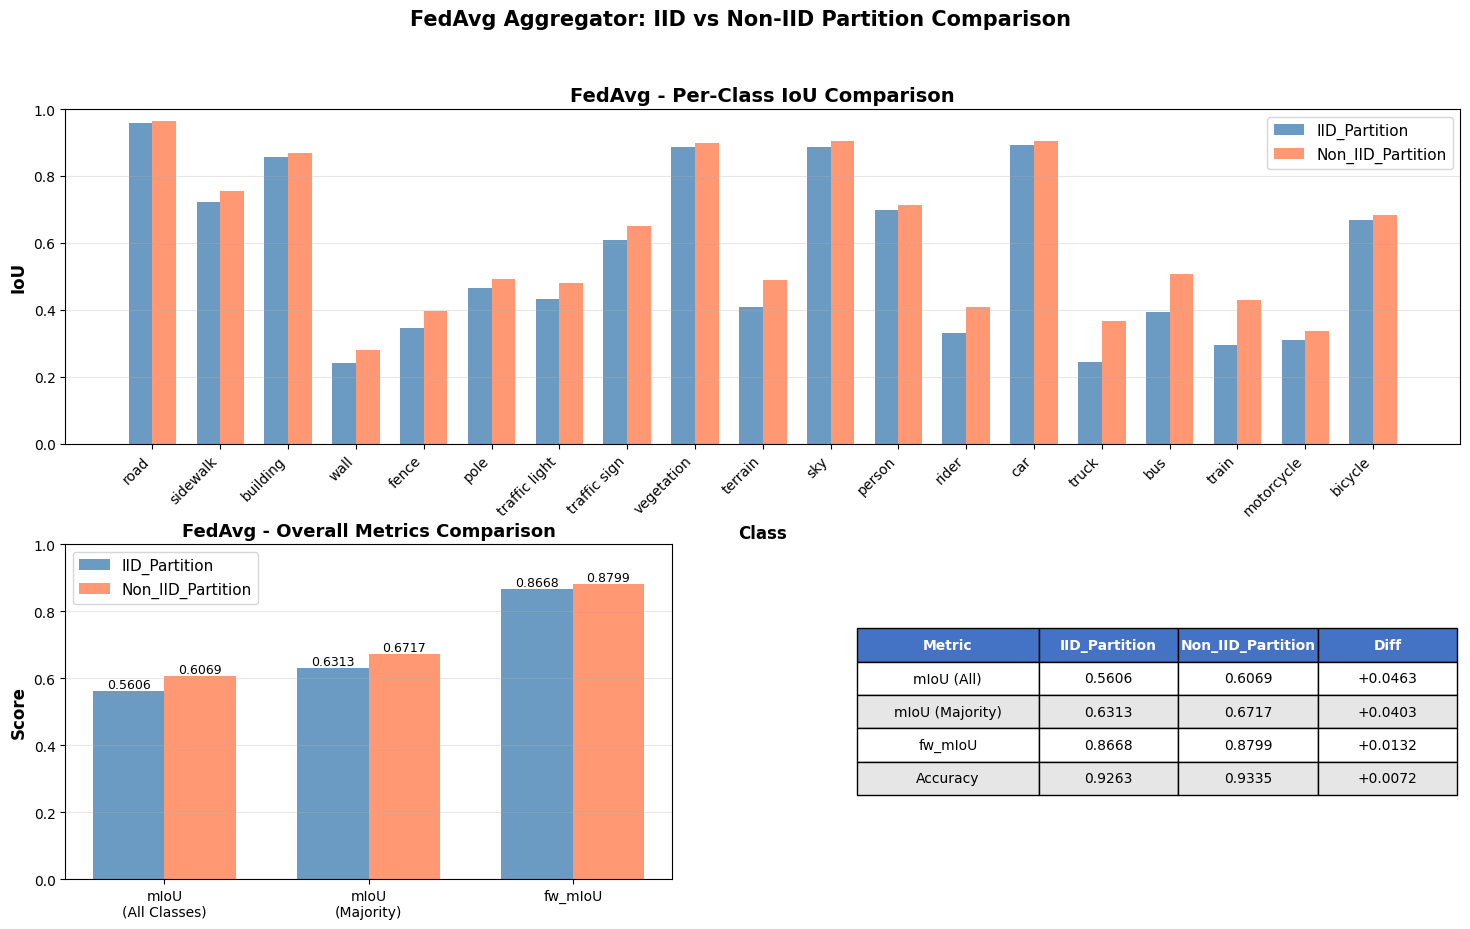

✓ Saved: fedavg_comparison.png

Generating FedProx Comparison Plot



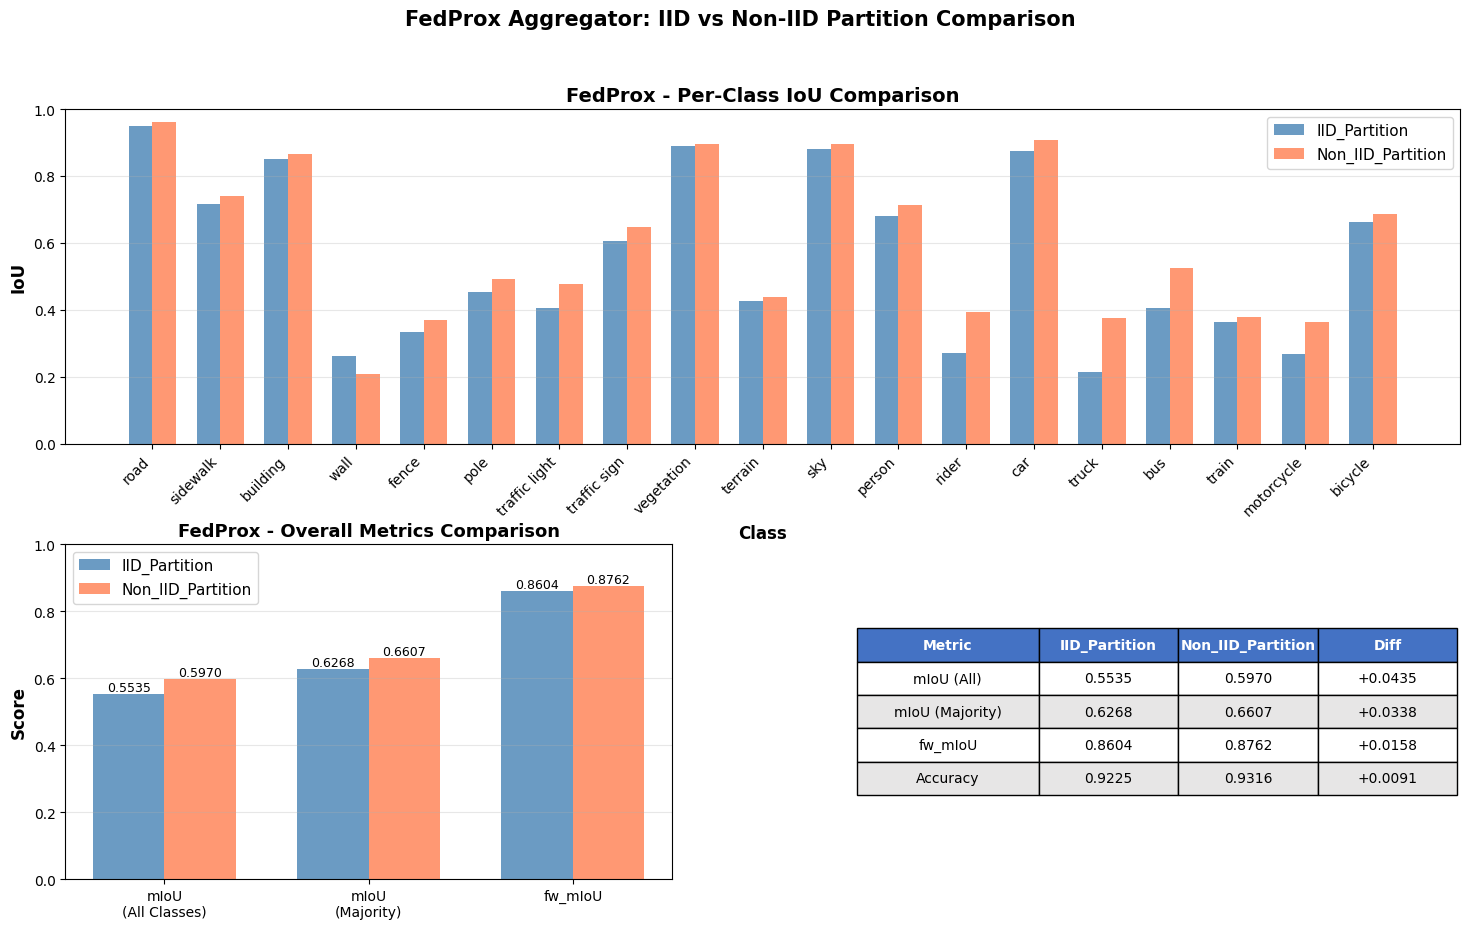

✓ Saved: fedprox_comparison.png


In [8]:
def plot_aggregator_comparison(partition_results, aggregator_name, partition_types, class_names, majority_indices):
    """
    Compare performance between IID and Non-IID partitions for a given aggregator.
    
    Args:
        partition_results: Dictionary with (partition_type, aggregator) -> results
        aggregator_name: Name of aggregator to compare (e.g., "FedAvg", "FedProx")
        partition_types: List of partition types to compare
        class_names: Dictionary mapping class ID to class name
        majority_indices: Set of majority class indices
    
    Returns:
        fig: matplotlib figure object
    """
    # Extract data for both partitions
    results_data = {}
    for partition_type in partition_types:
        key = (partition_type, aggregator_name)
        if key in partition_results:
            results_data[partition_type] = partition_results[key]
    
    if len(results_data) != 2:
        print(f"⚠ Could not find data for both partitions with {aggregator_name}")
        return None
    
    # Create figure with subplots
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
    
    # Extract metrics for both partitions
    partition_list = sorted(results_data.keys())
    
    iou_all_partitions = []
    metrics_all_partitions = []
    
    for partition_type in partition_list:
        iou_all_partitions.append(results_data[partition_type]['iou_per_class'])
        metrics_all_partitions.append(results_data[partition_type]['metrics_all_classes'])
    
    # ==================== Plot 1: Per-Class IoU Comparison ====================
    ax1 = fig.add_subplot(gs[0, :])
    
    x = np.arange(len(class_names))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, iou_all_partitions[0], width, 
                    label=partition_list[0], alpha=0.8, color='steelblue')
    bars2 = ax1.bar(x + width/2, iou_all_partitions[1], width, 
                    label=partition_list[1], alpha=0.8, color='coral')
    
    ax1.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax1.set_ylabel('IoU', fontsize=12, fontweight='bold')
    ax1.set_title(f'{aggregator_name} - Per-Class IoU Comparison', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels([class_names[i] for i in range(len(class_names))], rotation=45, ha='right')
    ax1.legend(fontsize=11)
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_ylim([0, 1.0])
    
    # ==================== Plot 2: Overall Metrics Comparison ====================
    ax2 = fig.add_subplot(gs[1, 0])
    
    metrics_names = ['mIoU\n(All Classes)', 'mIoU\n(Majority)', 'fw_mIoU']
    metrics_values_partition1 = [
        metrics_all_partitions[0]['mIoU'],
        np.mean(iou_all_partitions[0][list(majority_indices)]),
        metrics_all_partitions[0]['fw_mIoU']
    ]
    metrics_values_partition2 = [
        metrics_all_partitions[1]['mIoU'],
        np.mean(iou_all_partitions[1][list(majority_indices)]),
        metrics_all_partitions[1]['fw_mIoU']
    ]
    
    x_metrics = np.arange(len(metrics_names))
    width_metrics = 0.35
    
    bars1 = ax2.bar(x_metrics - width_metrics/2, metrics_values_partition1, width_metrics, 
                    label=partition_list[0], alpha=0.8, color='steelblue')
    bars2 = ax2.bar(x_metrics + width_metrics/2, metrics_values_partition2, width_metrics, 
                    label=partition_list[1], alpha=0.8, color='coral')
    
    # Add value labels on top of bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    
    ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax2.set_title(f'{aggregator_name} - Overall Metrics Comparison', fontsize=13, fontweight='bold')
    ax2.set_xticks(x_metrics)
    ax2.set_xticklabels(metrics_names, fontsize=10)
    ax2.legend(fontsize=11)
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_ylim([0, 1.0])
    
    # ==================== Plot 3: Metrics Table ====================
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.axis('off')
    
    table_data = []
    table_data.append(['Metric', partition_list[0], partition_list[1], 'Diff'])
    
    for metric_idx, metric_name in enumerate(['mIoU (All)', 'mIoU (Majority)', 'fw_mIoU', 'Accuracy']):
        if metric_idx == 0:
            val1 = metrics_all_partitions[0]['mIoU']
            val2 = metrics_all_partitions[1]['mIoU']
        elif metric_idx == 1:
            val1 = np.mean(iou_all_partitions[0][list(majority_indices)])
            val2 = np.mean(iou_all_partitions[1][list(majority_indices)])
        elif metric_idx == 2:
            val1 = metrics_all_partitions[0]['fw_mIoU']
            val2 = metrics_all_partitions[1]['fw_mIoU']
        else:
            val1 = metrics_all_partitions[0]['Accuracy']
            val2 = metrics_all_partitions[1]['Accuracy']
        
        diff = val2 - val1
        table_data.append([
            metric_name,
            f'{val1:.4f}',
            f'{val2:.4f}',
            f'{diff:+.4f}'
        ])
    
    table = ax3.table(cellText=table_data, cellLoc='center', loc='center',
                     colWidths=[0.3, 0.23, 0.23, 0.23])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Style header row
    for i in range(4):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Alternate row colors
    for i in range(1, len(table_data)):
        for j in range(4):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#E7E6E6')
    
    plt.suptitle(f'{aggregator_name} Aggregator: IID vs Non-IID Partition Comparison', 
                 fontsize=15, fontweight='bold', y=0.98)
    
    return fig

# Generate comparison plots for FedAvg
print(f"\n{'='*70}")
print("Generating FedAvg Comparison Plot")
print(f"{'='*70}\n")

fig_fedavg = plot_aggregator_comparison(
    partition_results, 
    "FedAvg", 
    PARTITION_IDS,
    CLASS_NAMES,
    MAJORITY_CLASS_INDICES
)

if fig_fedavg is not None:
    plt.savefig('fedavg_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: fedavg_comparison.png")

# Generate comparison plots for FedProx
print(f"\n{'='*70}")
print("Generating FedProx Comparison Plot")
print(f"{'='*70}\n")

fig_fedprox = plot_aggregator_comparison(
    partition_results, 
    "FedProx", 
    PARTITION_IDS,
    CLASS_NAMES,
    MAJORITY_CLASS_INDICES
)

if fig_fedprox is not None:
    plt.savefig('fedprox_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: fedprox_comparison.png")